## Load Database

In [1]:
# Code to assess Postgres SQL came from previous class assignment
# Import Packages
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")

def execute_query(query):
    try:
        # connect to a PostgresSQL database
        conn = psycopg2.connect(
        host="localhost",
        database="Capstone",   # sepcify dataabse to connect to
        user="postgres",        # deafult user name
        password="Boeing747!")      # password
        
        # create a cursor
        cur = conn.cursor()
        # execute query
        cur.execute(query)
        
        # fetch the result and store into a python dataframe
        rows=cur.fetchall()
        colnames = [desc[0] for desc in cur.description]
        return pd.DataFrame(rows, columns = colnames)
        
    except (Exception, psycopg2.DatabaseError) as error:
        print(error)
    finally:
        if conn is not None:
            conn.close()        # close the communication with the PostgreSQL

In [2]:
# Pull data
query = """
SELECT * FROM accidents;
"""
df = execute_query(query)

# Display data
pd.set_option('display.max.columns',None)
df.head(3)

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,Other Accident Year,Other Accident Month,Maintenance Railroad Code,Maintenance Railroad Name,Maintenance Accident Number,Maintenance Accident Year,Maintenance Accident Month,Grade Crossing ID,Day,Date,Time,Accident Type Code,Accident Type,Hazmat Cars,Hazmat Cars Damaged,Hazmat Released Cars,Persons Evacuated,Subdivision,Division Code,Division,Station,Milepost,State Code,State Abbreviation,State Name,County Code,County Name,District,Temperature,Visibility Code,Visibility,Weather Condition Code,Weather Condition,Track Type Code,Track Type,Track Name,Track Class,Track Density,Train Direction Code,Train Direction,Equipment Type Code,Equipment Type,Equipment Attended,Train Number,Train Speed,Recorded Estimated Speed,Maximum Speed,Gross Tonnage,Signalization Code,Signalization,Method of Operation Code,Method of Operation,Adjunct Code 1,Adjunct Name 1,Adjunct Code 2,Adjunct Name 2,Adjunct Code 3,Adjunct Name 3,Remote Control Locomotive Code,Remote Control Locomotive,First Car Initials,First Car Number,First Car Position,First Car Loaded,Causing Car Initials,Causing Car Number,Causing Car Position,Causing Car Loaded,Positive Alcohol Tests,Positive Drug Tests,Passengers Transported,Head End Locomotives,Mid Train Manual Locomotives,Mid Train Remote Locomotives,Rear End Manual Locomotives,Rear End Remote Locomotives,Derailed Head End Locomotives,Derailed Mid Train Manual Locomotives,Derailed Mid Train Remote Locomotives,Derailed Rear End Manual Locomotives,Derailed Rear End Remote Locomotives,Loaded Freight Cars,Loaded Passenger Cars,Empty Freight Cars,Empty Passenger Cars,Cabooses,Derailed Loaded Freight Cars,Derailed Loaded Passenger Cars,Derailed Empty Freight Cars,Derailed Empty Passenger Cars,Derailed Cabooses,Equipment Damage Cost,Track Damage Cost,Total Damage Cost,Primary Accident Cause Code,Primary Accident Cause,Contributing Accident Cause Code,Contributing Accident Cause,Accident Cause Code,Accident Cause,Engineers On Duty,Firemen On Duty,Conductors On Duty,Brakemen On Duty,Hours Engineers On Duty,Minutes Engineers On Duty,Hours Conductors On Duty,Minutes Conductors On Duty,Railroad Employees Killed,Railroad Employees Injured,Passengers Killed,Passengers Injured,Others Killed,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Special Study 1,Special Study 2,Latitude,Longitude,Narrative,Joint Track Type,Joint Track Class,Class Code,Class,Joint CD,Incident Key,Report Key,Reporting Railroad Class,Reporting Railroad SMT Grouping,Reporting Parent Railroad Code,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,CSX,CSX Transportation,2010,74979,https://safetydata.fra.dot.gov/Officeofsafety/...,10,4,None,None,None,NaN,NaN,CSX,CSX Transportation,74979,10.0,4.0,None,16,4/16/2010,1:15 AM,1,Derailment,0,0,0,0,None,ALBANY,ALBANY,SELKIRK,15,36,NY,NEW YORK,1.0,ALBANY,1,53,4.0,Dark,3.0,Rain,2,Yard,SOUTH MASTER,1,0,3,East,5,Single Car,No,None,4.0,Estimated,4.0,0,NaN,None,LN,None,None,None,None,None,None,None,0,Not a remotely controlled operation,ASOX,58690,1.0,No,ASOX,58690.0,1.0,No,NaN,NaN,No,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,17189,1200,18389,E67C,Damaged flange or tread (build up),None,None,E67C,Damaged flange or tread (build up),0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,0.0,0.0,DERAILED AT RETARDER DUE TO EXCESSIVE BUILD UP.,Yard,1,1,1,1,CSX000074979201004,CSX000074979201004,Class I,SMT-9 - CSX,CSX,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigne

In [3]:
# Dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224704 entries, 0 to 224703
Columns: 155 entries, Reporting Railroad Code to Location
dtypes: float64(25), int64(49), object(81)
memory usage: 265.7+ MB


In [4]:
# Check data shape
df.shape

(224704, 155)

In [5]:
# Check summary stats
df.describe()

,Year,Accident Year,Accident Month,Other Accident Year,Other Accident Month,Maintenance Accident Year,Maintenance Accident Month,Day,Accident Type Code,Hazmat Cars,Hazmat Cars Damaged,Hazmat Released Cars,Persons Evacuated,State Code,County Code,District,Temperature,Visibility Code,Weather Condition Code,Train Speed,Maximum Speed,Gross Tonnage,Signalization Code,First Car Position,Causing Car Number,Causing Car Position,Positive Alcohol Tests,Positive Drug Tests,Head End Locomotives,Mid Train Manual Locomotives,Mid Train Remote Locomotives,Rear End Manual Locomotives,Rear End Remote Locomotives,Derailed Head End Locomotives,Derailed Mid Train Manual Locomotives,Derailed Mid Train Remote Locomotives,Derailed Rear End Manual Locomotives,Derailed Rear End Remote Locomotives,Loaded Freight Cars,Loaded Passenger Cars,Empty Freight Cars,Empty Passenger Cars,Cabooses,Derailed Loaded Freight Cars,Derailed Loaded Passenger Cars,Derailed Empty Freight Cars,Derailed Empty Passenger Cars,Derailed Cabooses,Equipment Damage Cost,Track Damage Cost,Total Damage Cost,Engineers On Duty,Firemen On Duty,Conductors On Duty,Brakemen On Duty,Hours Engineers On Duty,Minutes Engineers On Duty,Hours Conductors On Duty,Minutes Conductors On Duty,Railroad Employees Killed,Railroad Employees Injured,Passengers Killed,Passengers Injured,Others Killed,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Latitude,Longitude,Joint CD
count,224704.000000,224704.000000,224704.000000,19502.000000,19502.000000,224702.000000,224702.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,221055.000000,224704.000000,224704.000000,224465.000000,224312.000000,224702.000000,224704.000000,224704.000000,37570.000000,211348.000000,26427.000000,107098.000000,78916.000000,79205.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,2.247040e+05,2.247040e+05,2.247040e+05,199038.000000,184614.00000,197111.000000,190859.000000,176489.000000,167594.000000,170363.000000,162556.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,70136.000000,70152.000000,224704.000000
mean,1993.240200,57.764641,6.432872,57.673110,6.440929,57.764942,6.432876,15.684420,3.406508,1.354395,0.176459,0.016413,2.074850,29.268629,94.890584,4.409962,56.180095,2.831515,1.558793,11.607645,13.421151,3185.369402,1.702103,21.563890,219457.990199,8.105996,0.004955,0.006969,1.985100,0.014174,0.017263,0.047342,0.028202,0.141769,0.001032,0.001455,0.003222,0.002323,29.659134,0.212684,16.494566,0.081952,0.277138,2.369815,0.017614,1.095806,0.010000,0.036666,4.374842e+04,1.777318e+04,7.815716e+04,0.935218,0.10718,0.876141,1.040711,4.687408,26.801085,4.625429,26.339428,0.002109,0.057035,0.000877,0.045580,0.010832,0.032385,0.015078,0.158974,0.019417,0.210566,0.010378,0.126869,20.263719,-49.744623,1.311508
std,15.200545,35.285135,3.453805,35.158877,3.461773,35.285149,3.453787,8.753871,3.902550,6.391976,1.037951,0.272891,143.245314,15.312463,95.075204,1.952934,22.995552,1.032728,0.987067,15.245363,15.910348,4395.418992,0.457340,28.422412,278946.002192,21.269043,0.079683,0.091018,1.537901,0.219293,0.223655,0.316720,0.214434,0.541746,0.048463,0.054870,0.081858,0.062963,33.563973,1.677979,26.349023,0.910165,1.660067,4.343923,0.350662,3.355111,0.172761,2.388762,2.181525e+05,1.249053e+05,3.530435e+05,0.365798,0.31426,0.379462,0.897437,2.887727,17.027758,2.936813,17.257065,0.061685,0.426506,0.118978,2.290319,0.134842,2.545053,0.206705,3.435767,0.259472,3.844788,0.183276,3.406570,19.174951,47.166292,0.678269
min,19

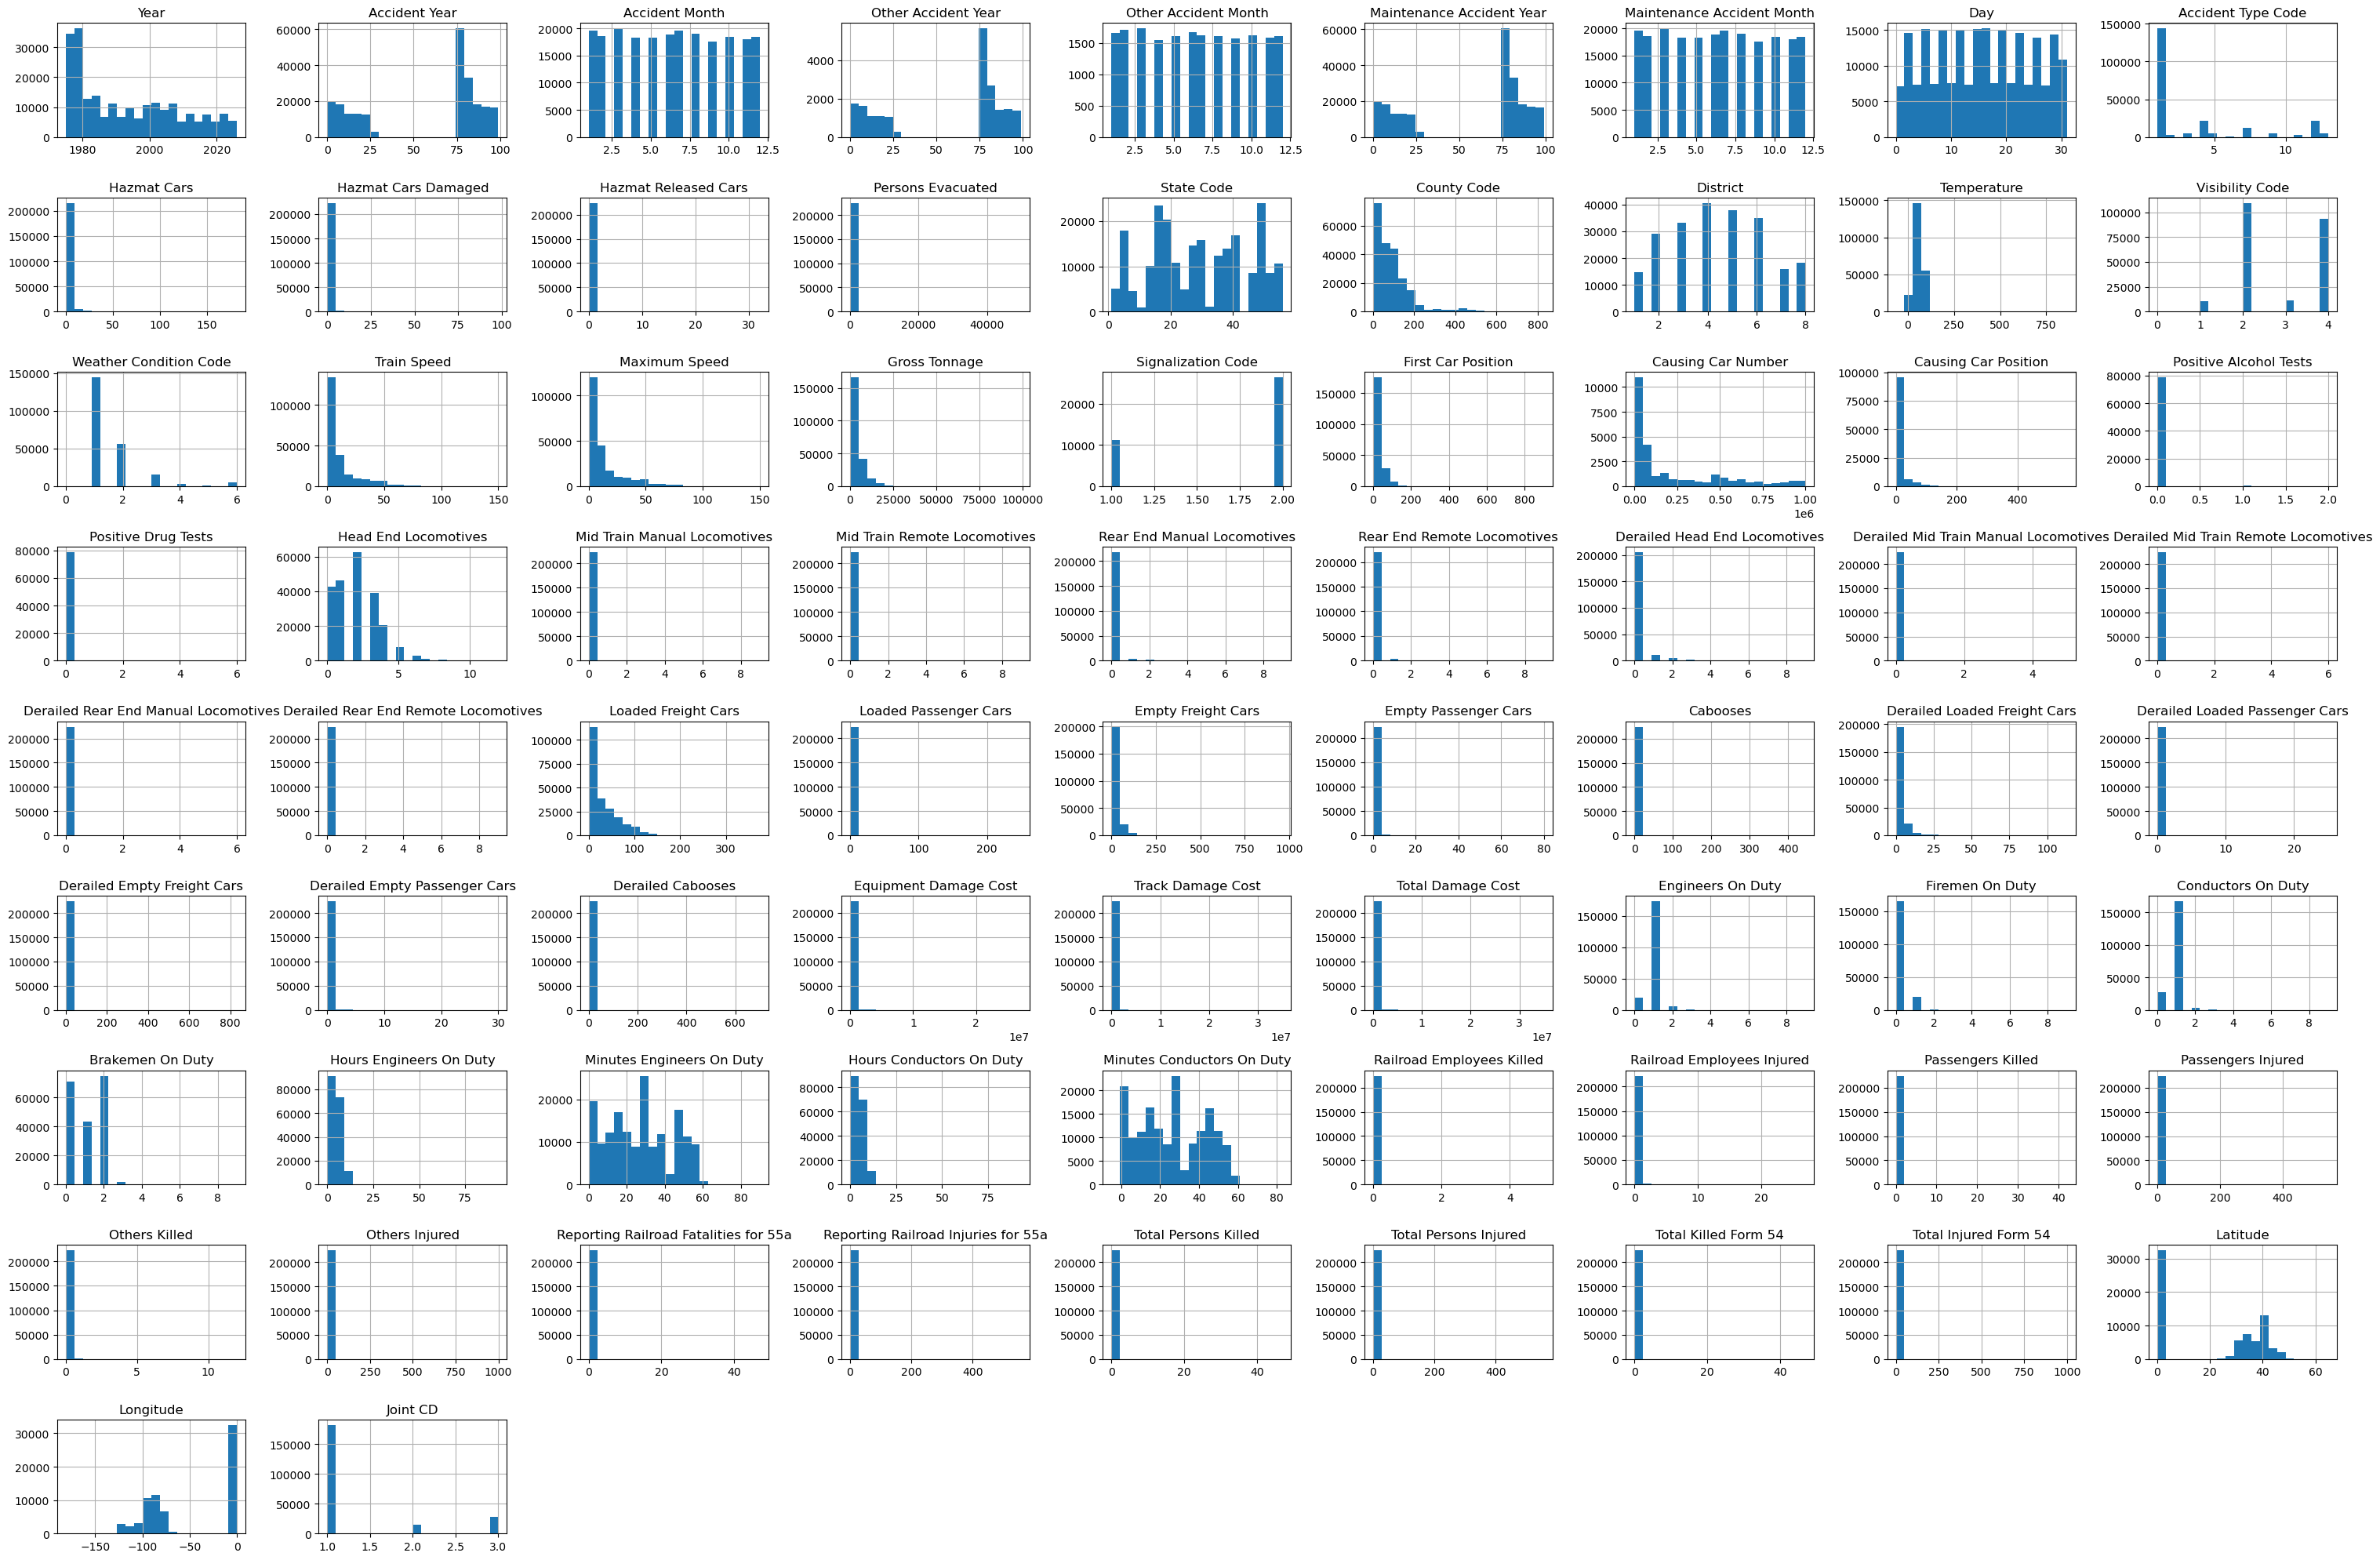

In [6]:
# Display distribution of numeric features
dist = df.hist(figsize=(30,20), bins = 20)
plt.tight_layout()
plt.show()

## Feature Selection

### Feature Name Correction

In [7]:
# Reformatting column names
# Turn columns to lowercase
df.columns = df.columns.str.lower()

# Remove space between columns
df.columns = df.columns.str.replace(" ","")
df.columns

Index(['reportingrailroadcode', 'reportingrailroadname', 'year',
       'accidentnumber', 'pdflink', 'accidentyear', 'accidentmonth',
       'otherrailroadcode', 'otherrailroadname', 'otheraccidentnumber',
       ...
       'reportingparentrailroadname', 'reportingrailroadholdingcompany',
       'reportingrailroadindividualclass', 'reportingrailroadpassenger',
       'reportingrailroadcommuter', 'reportingrailroadswitchingterminal',
       'reportingrailroadtourist', 'reportingrailroadfreight',
       'reportingrailroadshortline', 'location'],
      dtype='object', length=155)

### Duplicated Review

In [8]:
# Total number of duplicated values
df.duplicated().sum()

np.int64(5)

In [9]:
# Display duplicates
df[df.duplicated()]

,reportingrailroadcode,reportingrailroadname,year,accidentnumber,pdflink,accidentyear,accidentmonth,otherrailroadcode,otherrailroadname,otheraccidentnumber,otheraccidentyear,otheraccidentmonth,maintenancerailroadcode,maintenancerailroadname,maintenanceaccidentnumber,maintenanceaccidentyear,maintenanceaccidentmonth,gradecrossingid,day,date,time,accidenttypecode,accidenttype,hazmatcars,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,subdivision,divisioncode,division,station,milepost,statecode,stateabbreviation,statename,countycode,countyname,district,temperature,visibilitycode,visibility,weatherconditioncode,weathercondition,tracktypecode,tracktype,trackname,trackclass,trackdensity,traindirectioncode,traindirection,equipmenttypecode,equipmenttype,equipmentattended,trainnumber,trainspeed,recordedestimatedspeed,maximumspeed,grosstonnage,signalizationcode,signalization,methodofoperationcode,methodofoperation,adjunctcode1,adjunctname1,adjunctcode2,adjunctname2,adjunctcode3,adjunctname3,remotecontrollocomotivecode,remotecontrollocomotive,firstcarinitials,firstcarnumber,firstcarposition,firstcarloaded,causingcarinitials,causingcarnumber,causingcarposition,causingcarloaded,positivealcoholtests,positivedrugtests,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,equipmentdamagecost,trackdamagecost,totaldamagecost,primaryaccidentcausecode,primaryaccidentcause,contributingaccidentcausecode,contributingaccidentcause,accidentcausecode,accidentcause,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,hoursengineersonduty,minutesengineersonduty,hoursconductorsonduty,minutesconductorsonduty,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,specialstudy1,specialstudy2,latitude,longitude,narrative,jointtracktype,jointtrackclass,classcode,class,jointcd,incidentkey,reportkey,reportingrailroadclass,reportingrailroadsmtgrouping,reportingparentrailroadcode,reportingparentrailroadname,reportingrailroadholdingcompany,reportingrailroadindividualclass,reportingrailroadpassenger,reportingrailroadcommuter,reportingrailroadswitchingterminal,reportingrailroadtourist,reportingrailroadfreight,reportingrailroadshortline,location
112779,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,None,None,None,NaN,NaN,UP,Union Pacific Railroad Company,0885NP001,85.0,8.0,None,1,8/1/1985,10:30 AM,4,Side collision,0,0,0,0,None,NEBRAS,NEBRASKA,NORTH PLATTE,None,31,NE,NEBRASKA,111.0,LINCOLN,6,69,2.0,Day,2.0,Cloudy,2,Yard,FORWARDING TRACK,2,None,4,West,6,Cut of cars,No,CUT,0.0,Estimated,10.0,0,NaN,None,N,None,None,None,None,None,None,None,None,None,TTGX,962651,18.0,Yes,None,NaN,NaN,None,NaN,NaN,No,0,0,0,0,0,0,0,0,0,0,38,0,1,0,0,3,0,0,0,0,75000,0,368600,H306,"Shoving movement, absence of man on or at lead...",None,None,H306,"Shoving movement, absence of man on or at lead...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,1,0,0,None,None,NaN,NaN,SEE OTHER REPORTNoneNoneNoneNoneNoneNoneNoneNo...,Yard,2,1L,1L,3,UP0885NP001198508,UP0885NP001198508,Class I,SMT-6 - UP/KCS,UP,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,None
114965,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,None,None,None,NaN,NaN,UP,Union Pacific Railroad 

In [10]:
# Remove duplicates due to identical ID numbers
df = df.drop_duplicates()
print(df.duplicated().sum())

0


### Missing Value Exploration

In [11]:
# Check missing values
# Reformat pd setup options
pd.set_option('display.max_rows', None)
missing_values = df.isnull().sum()
missing_values

reportingrailroadcode                      0
reportingrailroadname                      3
year                                       0
accidentnumber                             0
pdflink                                    4
accidentyear                               0
accidentmonth                              0
otherrailroadcode                     205201
otherrailroadname                     205256
otheraccidentnumber                   205194
otheraccidentyear                     205197
otheraccidentmonth                    205197
maintenancerailroadcode                    3
maintenancerailroadname                   89
maintenanceaccidentnumber                  2
maintenanceaccidentyear                    2
maintenanceaccidentmonth                   2
gradecrossingid                       212588
day                                        0
date                                       1
time                                       0
accidenttypecode                           0
accidentty

In [12]:
# Features with more then 25% of records being 'Null' were filter for analysis
missing_percent = df.isnull().sum() * 100 / len(df) # Missing values / total
df2 = pd.DataFrame({'Percent Missing': missing_percent}) # Seperate into features
percent_miss_df = df2[df2['Percent Missing'] > 10.0] # Slice the data that is over 10% missing
percent_miss_df

,Percent Missing
otherrailroadcode,91.322614
otherrailroadname,91.347091
otheraccidentnumber,91.319499
otheraccidentyear,91.320834
otheraccidentmonth,91.320834
gradecrossingid,94.610123
subdivision,83.281190
divisioncode,19.871473
division,18.568841
milepost,13.164278


In [13]:
# df['name'].value_counts() was used to analyze and determine solution
# Handle "Nulls" intensionally
df['positivealcoholtests'] = df['positivealcoholtests'].fillna(0.0)
df['positivedrugtests'] = df['positivedrugtests'].fillna(0.0)
df['equipmentattended'] = df['equipmentattended'].fillna('Unknown')
df['trainspeed'] = df['trainspeed'].fillna(df['trainspeed'].median())
df['passengerstransported'] = df['passengerstransported'].fillna('Unknown')

# Change data type found during exploration
df['district'] = df['district'].astype('str')
df['visibilitycode'] = df['visibilitycode'].astype('str')
df['weatherconditioncode'] = df['weatherconditioncode'].astype('str')

# Filter out "confusing" values
# Group_A
df = df[df['recordedestimatedspeed'].isin(['Estimated','Recorded'])]
df = df[df['accidenttype'] != 'Other (describe in narrative)']
df = df[(df['temperature'] < 110) & (df['temperature'] > -20)]
df = df[df['visibilitycode'] != 0.0]
df = df[df['loadedfreightcars'] <= 140]
df = df[df['emptyfreightcars'] <= 140]
df = df[df['emptypassengercars'] <= 20]
df = df[df['cabooses'] <= 5]

#Group_B
df = df[df['derailedloadedpassengercars'] <= 12]
df = df[df['derailedloadedfreightcars'] <= 50]
df = df[df['derailedrearendremotelocomotives'] <= 2]
df = df[df['derailedrearendmanuallocomotives'] <= 4]
df = df[df['derailedemptyfreightcars'] <= 40]
df = df[df['derailedemptypassengercars'] <= 6]
df = df[df['derailedcabooses'] <= 4]
df = df[df['hazmatcarsdamaged'] <= 20]
df = df[df['hazmatreleasedcars'] <= 7]
df = df[df['hazmatreleasedcars'] <= 7]
df = df[df['positivedrugtests'] <= 2.0]

# Fixing date features
drop_year = ['accidentyear']
# Drop columns from list and review shape
df = df.drop(columns = drop_year, errors = 'ignore')
df = df.rename(columns={'year': 'accidentyear'})
df = df.rename(columns={'day': 'accidentday'})

# Reformatting time into two columns for modeling
df['time'] = pd.to_datetime(df['time'], format = ('%I:%M %p'), errors = 'coerce') # Extra time formatting and convert unreadable values to NA
df['accidenthour'] = df['time'].dt.hour
df['accidentminute'] = df['time'].dt.minute

# Dropping the existing time column
df = df.drop(columns = 'time', axis =1)

### Column Description for Model Features

1) 'reportingrailroadcode': Code of the reporting railroad.
2) 'maintenancerailroadcode': Code of the railroad responsible for track maintenance.
3) 'accidentyear': Year of accident.
4) 'accidentmonth': Month of accident.
5) 'accidentday': Day of accident.
6) 'accidenthour': Hour accident took place.
7) 'accidentminute': Minute accident took place. 
8) 'accidenttype': Type of accident.
9) 'division': Railroad division.
10) 'stateabbreviation': Two letter abbreviation of state.
11) 'countyname': Name of county. 
12) 'district': FRA assigned geographical district.
13) 'hazmatcars': Number of hazmat cars involved. 
14) 'temperature': Temperature recorded at time of accident, in Fahrenheit.
15) 'visibilitycode': Visibility code recorded at time of accident.
16) 'visibility': Visibility recorded at time of accident.
17) 'weatherconditioncode': Weather condition code recorded at time of accident.
18) 'tracktype': Type of track.
19) 'grosstonnage': Trailing tons, gross tonnage, excluding power units.
20) 'passengerstransported': Yes/No if passengers were being transported. 
21) 'headendlocomotives': Number of head end locomotives.
22) 'midtrainmanuallocomotives': Number of mid train locomotives, manual.
23) 'midtrainremotelocomotives': Number of mid train locomotives, remote.
24) 'rearendmanuallocomotives': Number of rear end locomotives, manual.
25) 'rearendremotelocomotives': Number of rear end locomotives, remote.
26) 'loadedfreightcars': Number of loaded freight cars.
27) 'loadedpassengercars': Number of loaded passenger cars.
28) 'emptyfreightcars': Number of empty freight cars.
29) 'emptypassengercars': Number of empty passenger cars.
30) 'cabooses': Number of cabooses.  

### Dataframe Selection

In [14]:
# Claude AI was used for efficiency. Based on the provided prompt following prompt, gave advice on what features to seperate into each group.
# Further switching and adjustments where made based upon further investigation.
group = ['reportingrailroadcode',
         'maintenancerailroadcode',
         'accidentyear',
         'accidentmonth', 
         'accidenttype',
         'division', 
         'stateabbreviation',
         'countyname', 
         'district',
         'hazmatcars', 
         'temperature', 
         'visibilitycode', 
         'visibility',
         'weatherconditioncode', 
         'tracktype', 
         'grosstonnage',
         'passengerstransported',
         'headendlocomotives', 
         'midtrainmanuallocomotives',
         'midtrainremotelocomotives', 
         'rearendmanuallocomotives',
         'rearendremotelocomotives', 
         'loadedfreightcars',
         'loadedpassengercars', 
         'emptyfreightcars', 
         'emptypassengercars',
         'cabooses', 
         'totaldamagecost',
         'totalpersonskilled',
         'totalpersonsinjured']

# # Examining Group A
df = df[group]
df.head(5)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidenttype,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,visibility,weatherconditioncode,tracktype,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,totaldamagecost,totalpersonskilled,totalpersonsinjured
0,CSX,CSX,2010,4,Derailment,ALBANY,NY,ALBANY,1,0,53,4.0,Dark,3.0,Yard,0,No,0,0,0,0,0,0,0,1,0,0,18389,0,0
1,BNSF,BNSF,2010,12,Derailment,KANSAS,KS,COWLEY,6,0,35,2.0,Day,2.0,Main,14755,No,3,0,0,0,1,114,0,1,0,0,580746,0,0
2,RT,RT,1989,10,Derailment,SYSTEM,OH,CUYAHOGA,2,0,60,4.0,Dark,2.0,Yard,0,No,2,0,0,0,0,16,0,0,0,0,20000,0,0
3,CO,CO,1983,6,Side collision,OHIO,OH,SENECA,2,0,70,4.0,Dark,1.0,Yard,0,No,0,0,0,0,0,34,0,2,0,0,14000,0,0
4,BN,BN,1981,1,Rear end collision,DAKOTA,ND,CASS,8,0,5,4.0,Dark,2.0,Industry,0,No,0,0,0,0,0,0,0,4,0,0,13500,0,0


In [15]:
# Evaluate the new dataset missing values.
df.isnull().sum()

reportingrailroadcode            0
maintenancerailroadcode          2
accidentyear                     0
accidentmonth                    0
accidenttype                     0
division                     35932
stateabbreviation                0
countyname                    3282
district                         0
hazmatcars                       0
temperature                      0
visibilitycode                   0
visibility                     150
weatherconditioncode             0
tracktype                     2120
grosstonnage                     0
passengerstransported            0
headendlocomotives               0
midtrainmanuallocomotives        0
midtrainremotelocomotives        0
rearendmanuallocomotives         0
rearendremotelocomotives         0
loadedfreightcars                0
loadedpassengercars              0
emptyfreightcars                 0
emptypassengercars               0
cabooses                         0
totaldamagecost                  0
totalpersonskilled  

In [16]:
# Removed 'Null" records based on previous analysis
df = df.dropna()
# Double check work
df.shape

(159573, 30)

## Calculating Risk Score

### Train Test Split

In [17]:
# Split data
df_train, df_test, = train_test_split(df, test_size = 0.2, random_state = 42)

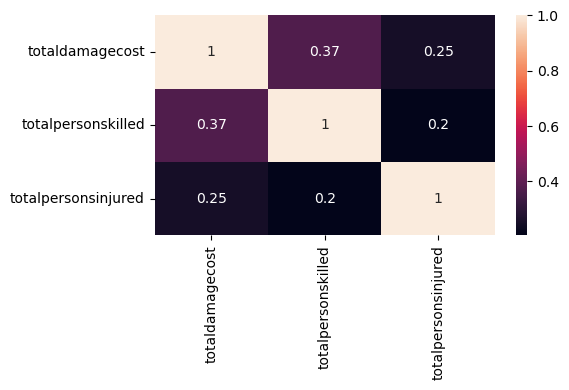

In [18]:
risk_ft = ['totaldamagecost', 'totalpersonskilled', 'totalpersonsinjured']

plt.figure(figsize = (6,4))
heat_data = df_train[risk_ft].corr(numeric_only=True)
ax = sns.heatmap(heat_data, annot = True)
plt.tight_layout()

In [19]:
from sklearn.preprocessing import MinMaxScaler
risk_ft = ['totaldamagecost', 'totalpersonskilled', 'totalpersonsinjured']
scaler = MinMaxScaler()

df_train[risk_ft] = scaler.fit_transform(df_train[risk_ft])
df_test[risk_ft] = scaler.transform(df_test[risk_ft])

df_train['risk_score'] = ((df_train['totaldamagecost']+df_train['totalpersonskilled']+df_train['totalpersonsinjured'])/3) * 100
df_test['risk_score'] = ((df_test['totaldamagecost']+df_test['totalpersonskilled']+df_test['totalpersonsinjured'])/3) * 100

In [20]:
df_train['risk_score'].describe()

count    127658.000000
mean          0.146306
std           0.668558
min           0.000000
25%           0.014964
50%           0.030518
75%           0.083575
max          61.871376
Name: risk_score, dtype: float64

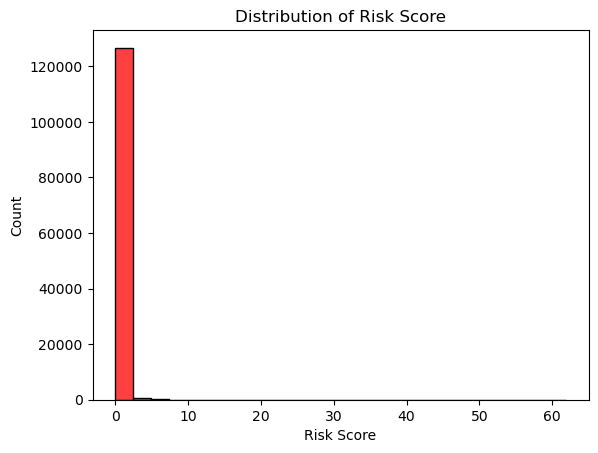

In [21]:
sns.histplot(data = df_train, x='risk_score', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()

In [22]:
from scipy.stats import skew
print(skew(df_train['risk_score']))

31.972997256285044


### Power Transformation

In [23]:
transformer = PowerTransformer(method='yeo-johnson') # Standardize data by default
df_train['risk_score_yeo'] = transformer.fit_transform(df_train[['risk_score']]) # Fit on the training data
df_test['risk_score_yeo'] = transformer.transform(df_test[['risk_score']]) # Fit on the training data

Text(0.5, 1.0, 'Probability Plot on Train After Yeo-Johnson')

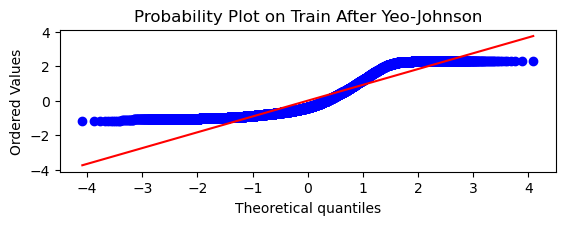

In [24]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
prob1 = stats.probplot(df_test['risk_score_yeo'], dist='norm', plot=ax1)
ax1.set_title('Probability Plot on Train After Yeo-Johnson')

In [25]:
print(skew(df_train['risk_score_yeo']))

1.024027428601325


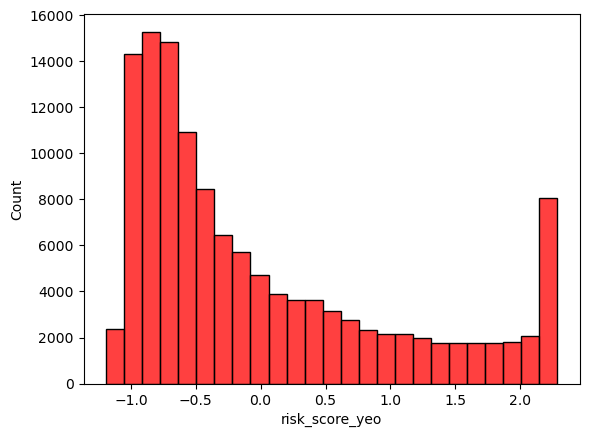

In [26]:
sns.histplot(data = df_train, x='risk_score_yeo', color = 'red', edgecolor = 'black', bins = 25)
plt.show()

In [27]:
high_values = df_train[df_train['risk_score_yeo']>2.0]
high_values.describe()

,accidentyear,accidentmonth,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,totaldamagecost,totalpersonskilled,totalpersonsinjured,risk_score,risk_score_yeo
count,10198.000000,10198.000000,10198.00000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000,10198.000000
mean,1993.427143,6.399882,2.49951,55.942538,5956.168366,2.768876,0.017356,0.023436,0.038831,0.067856,48.473034,0.611198,19.360953,0.077074,0.284369,0.029296,0.004738,0.002911,1.231528,2.215424
std,10.780293,3.448315,7.31052,23.657025,5538.673124,1.486702,0.243364,0.265613,0.295204,0.321356,39.033584,2.626190,28.430640,0.743539,0.465894,0.044314,0.018653,0.021591,2.066781,0.081402
min,1975.000000,1.000000,0.00000,-18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.337811,2.000083
25%,1984.000000,3.000000,0.00000,38.000000,1650.000000,2.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.011523,0.000000,0.000000,0.485004,2.168544
50%,1994.000000,6.000000,0.00000,58.000000,5112.000000,3.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000,3.000000,0.000000,0.000000,0.017307,0.000000,0.000000,0.731127,2.253409
75%,2003.000000,9.000000,1.00000,75.000000,8725.750000,4.000000,0.000000,0.000000,0.000000,0.000000,76.000000,0.000000,31.000000,0.000000,1.000000,0.032470,0.000000,0.001792,1.260091,2.281258
max,2011.000000,12.000000,96.00000,109.000000,97000.000000,9.000000,9.000000,8.000000,9.000000,4.000000,140.000000,105.000000,139.000000,17.000000,5.000000,1.000000,1.000000,1.000000,61.871376,2.284384


### Risk Category

In [29]:
df_train['risk_category'], bin_edges = pd.qcut(df_train['risk_score'], q=3, labels = ['Low Severity', 'Moderate Severity', 'High Severity'], retbins=True) # retbins: Returns bins and labels
df_test['risk_category'] = pd.cut(df_test['risk_score'], bins=bin_edges, labels = ['Low Severity', 'Moderate Severity', 'High Severity'], include_lowest=True) # include_lowest: Keeps the lowest value in

In [33]:
df_train['risk_category'].value_counts()

risk_category
Low Severity         42622
High Severity        42553
Moderate Severity    42483
Name: count, dtype: int64

In [32]:
df_test['risk_category'].value_counts()

risk_category
High Severity        10674
Moderate Severity    10638
Low Severity         10603
Name: count, dtype: int64

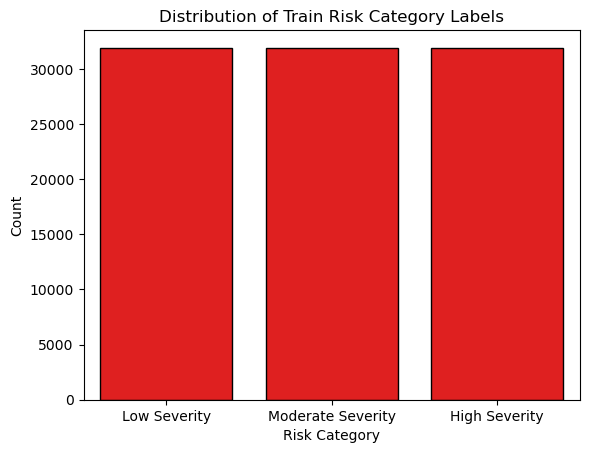

In [63]:
sns.countplot(df_train, x='risk_category', color = 'red', edgecolor = 'black')
plt.title('Distribution of Train Risk Category Labels')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.show()

In [31]:
df_train.groupby('risk_category')[['totaldamagecost', 'totalpersonskilled', 'totalpersonsinjured']].describe()

totaldamagecost                                     \
                            count      mean       std  min       25%   
risk_category                                                          
Low Severity              31914.0  0.000440  0.000169  0.0  0.000294   
Moderate Severity         31921.0  0.001261  0.000419  0.0  0.000914   
High Severity             31908.0  0.012651  0.031534  0.0  0.002796   

                                                totalpersonskilled            \
                        50%       75%       max              count      mean   
risk_category                                                                  
Low Severity       0.000442  0.000584  0.000737            31914.0  0.000000   
Moderate Severity  0.001174  0.001558  0.002204            31921.0  0.000000   
High Severity      0.004608  0.010415  1.000000            31908.0  0.003212   

                                                     totalpersonsinjured  \
                        std  min  25%  50%  75%  max               count   
risk_category                                                              
Low Severity       0.000000  0.0  0.0  0.0  0.0  0.0             31914.0   
Moderate Severity  0.000000  0.0  0.0  0.0  0.0  0.0             31921.0   
High Severity      0.022299  0.0  0.0  0.0  0.0  1.0             31908.0   

                                                                     
                       mean       std  min  25%  50%  75%       max  
risk_category                                                        
Low Severity       0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  
Moderate Severity  0.000021  0.000192  0.0  0.0  0.0  0.0  0.001792  
High Severity      0.001020  0.010580  0.0  0.0  0.0  0.0  1.000000

In [32]:
drop_list = ['totaldamagecost', 'totalpersonskilled', 'totalpersonsinjured','risk_score']
df_train = df_train.drop(columns = drop_list, axis=1)
df_test = df_test.drop(columns = drop_list, axis=1)

### Preparing Datasets

In [33]:
# KNN Target Variable
y_train_knn = df_train['risk_category']
y_test_knn = df_test['risk_category']

# Linear Regression Variable
y_train_lin = df_train['risk_score_yeo']
y_test_lin = df_test['risk_score_yeo']

# X_train and X_test
X_train = df_train.drop(columns=['risk_category','risk_score_yeo'])
X_test = df_test.drop(columns=['risk_category','risk_score_yeo'])

In [34]:
# Set features used for frequency
df_freq_encod = ['reportingrailroadcode',
                 'maintenancerailroadcode',
                 'stateabbreviation',
                 'district',
                 'division',
                 'countyname']

# Claude AI was used to help trouble shoot coding logic to avoid data leaking 
for i in df_freq_encod:
    frequency = X_train[i].value_counts(normalize=True) # Value count as a percentage per feature column
    X_train[i + 'fq'] = X_train[i].map(frequency) # Replace category value with it frequency value in training
    X_test[i + 'fq'] = X_test[i].map(frequency) # Follows the same principle, but in testing
    X_test[i + 'fq'] = X_test[i + 'fq'].fillna(0) # If not present, fill with 0

X_train = X_train.drop(columns = df_freq_encod) # Drop redundent columns
X_test = X_test.drop(columns = df_freq_encod) # Drop redundent columns

In [35]:
categorical_cols = X_train.select_dtypes(include=['object']).columns # Subset categorical features
encode = OneHotEncoder(sparse_output=False) # Implement One Hot Encoding
train_encode = encode.fit_transform(X_train[categorical_cols]) # Fit on train
test_encode = encode.transform(X_test[categorical_cols]) # Implement on test

# Created an array. Claude AI was used to help trouble shoot how to return a dataframe. 
train_encode_df = pd.DataFrame(train_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_train.index)
test_encode_df = pd.DataFrame(test_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_test.index)

X_train=X_train.drop(columns=categorical_cols).join(train_encode_df)
X_test=X_test.drop(columns=categorical_cols).join(test_encode_df)

In [36]:
continuous_cols = ['accidentyear','hazmatcars','temperature','grosstonnage','headendlocomotives','midtrainmanuallocomotives','midtrainremotelocomotives',
                   'rearendmanuallocomotives','rearendremotelocomotives','loadedfreightcars','loadedpassengercars','emptyfreightcars','emptypassengercars',
                   'cabooses']

scaler = StandardScaler() # Implement Standard Scaler
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols]) # Fit scale on train
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols]) # Implement on test

In [42]:
X_train['month_sin'] = np.sin(X_train['accidentmonth'] * (2 * np.pi / 12))
X_train['month_cos'] = np.cos(df_train['accidentmonth'] * (2 * np.pi / 12))

X_test['month_sin'] = np.sin(X_test['accidentmonth'] * (2 * np.pi / 12))
X_test['month_cos'] = np.cos(X_test['accidentmonth'] * (2 * np.pi / 12))

X_train=X_train.drop(columns=['accidentmonth'])
X_test=X_test.drop(columns=['accidentmonth'])

In [43]:
X_train.head(3)

,accidentyear,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq,accidenttype_Broken train collision,accidenttype_Derailment,accidenttype_Explosion-detonation,accidenttype_Fire/violent rupture,accidenttype_Head on collision,accidenttype_Hwy-rail crossing,accidenttype_Obstruction,accidenttype_Other impacts,accidenttype_RR grade crossing,accidenttype_Raking collision,accidenttype_Rear end collision,accidenttype_Side collision,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibility_Dark,visibility_Dawn,visibility_Day,visibility_Dusk,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,tracktype_Industry,tracktype_Main,tracktype_Siding,tracktype_Yard,passengerstransported_No,passengerstransported_Unknown,passengerstransported_Yes,month_sin,month_cos
134806,-0.780742,-0.219798,-0.030142,2.250631,0.530612,-0.064002,-0.067604,-0.146721,-0.107058,2.962831,-0.113408,-0.69463,-0.088155,1.400006,0.012544,0.012293,0.022686,0.150079,0.006444,0.001420,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-2.449294e-16,1.000000
135715,-0.780742,-0.219798,-0.210848,-0.495868,-0.124649,-0.064002,-0.067604,-0.146721,-0.107058,-0.336289,-0.113408,-0.69463,-0.088155,-0.678694,0.000773,0.000637,0.021902,0.184076,0.015855,0.008732,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-5.000000e-01,0.866025
203366,-1.145033,-0.219798,-1.069206,-0.795746,-0.779910,-0.064002,-0.067604,-0.146721,-0.107058,-0.996113,0.516774,-0.69463,-0.088155,-0.678694,0.003227,0.003092,0.005891,0.059075,0.001890,0.002789,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,5.000000e-01,0.866025


In [44]:
X_test.head(3)

,accidentyear,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq,accidenttype_Broken train collision,accidenttype_Derailment,accidenttype_Explosion-detonation,accidenttype_Fire/violent rupture,accidenttype_Head on collision,accidenttype_Hwy-rail crossing,accidenttype_Obstruction,accidenttype_Other impacts,accidenttype_RR grade crossing,accidenttype_Raking collision,accidenttype_Rear end collision,accidenttype_Side collision,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibility_Dark,visibility_Dawn,visibility_Day,visibility_Dusk,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,tracktype_Industry,tracktype_Main,tracktype_Siding,tracktype_Yard,passengerstransported_No,passengerstransported_Unknown,passengerstransported_Yes,month_sin,month_cos
6814,1.951445,-0.219798,0.240919,-0.795746,-1.435171,-0.064002,-0.067604,-0.146721,-0.107058,-0.996113,-0.113408,-0.575661,-0.088155,-0.678694,0.000303,0.000376,0.049466,0.068987,0.085071,0.010789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.000000e-01,0.866025
120940,0.038915,-0.219798,-0.707792,-0.795746,-0.779910,-0.064002,-0.067604,-0.146721,-0.107058,-0.996113,3.037505,-0.694630,-0.088155,-0.678694,0.019699,0.029924,0.049466,0.068987,0.019594,0.002705,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-2.449294e-16,1.000000
181694,-1.236106,-0.219798,-1.385443,0.431135,0.530612,-0.064002,-0.067604,-0.146721,-0.107058,0.700577,-0.113408,0.336439,-0.088155,1.400006,0.015113,0.014810,0.013306,0.150079,0.000982,0.000282,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,8.660254e-01,0.500000


In [48]:
# Correlation to Risk Score
corr = X_train.join(y_train_lin).corr(numeric_only=True)['risk_score_yeo'].sort_values(ascending=False)
print(corr)

risk_score_yeo                         1.000000
tracktype_Main                         0.334870
accidentyear                           0.323794
grosstonnage                           0.242497
loadedfreightcars                      0.208438
headendlocomotives                     0.173142
accidenttype_Hwy-rail crossing         0.148745
hazmatcars                             0.130817
maintenancerailroadcodefq              0.119477
reportingrailroadcodefq                0.108762
passengerstransported_Yes              0.097900
rearendremotelocomotives               0.083183
accidenttype_Head on collision         0.075304
loadedpassengercars                    0.071621
accidenttype_Rear end collision        0.050519
emptyfreightcars                       0.046922
divisionfq                             0.040837
temperature                            0.032547
visibility_Day                         0.027617
visibilitycode_2.0                     0.027617
weatherconditioncode_4.0               0

In [57]:
# Implement Decision Tree Regression
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train_lin)

importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                        Score
accidentyear                         0.174329
tracktype_Main                       0.112139
grosstonnage                         0.082893
countynamefq                         0.065817
temperature                          0.064334
loadedfreightcars                    0.057280
divisionfq                           0.048931
emptyfreightcars                     0.047349
stateabbreviationfq                  0.041833
maintenancerailroadcodefq            0.029871
month_sin                            0.029159
month_cos                            0.028809
headendlocomotives                   0.027638
reportingrailroadcodefq              0.025260
districtfq                           0.021554
hazmatcars                           0.019801
accidenttype_Hwy-rail crossing       0.009469
accidenttype_Head on collision       0.007150
weatherconditioncode_1.0             0.006791
loadedpassengercars                  0.006669
weatherconditioncode_2.0          

In [59]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train_knn)

importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                        Score
accidentyear                         0.138110
temperature                          0.081072
countynamefq                         0.078288
grosstonnage                         0.071556
loadedfreightcars                    0.067074
divisionfq                           0.061125
emptyfreightcars                     0.058132
tracktype_Main                       0.055274
stateabbreviationfq                  0.047963
month_cos                            0.038617
month_sin                            0.038609
maintenancerailroadcodefq            0.033732
headendlocomotives                   0.032166
reportingrailroadcodefq              0.030569
districtfq                           0.027039
hazmatcars                           0.015913
weatherconditioncode_1.0             0.009801
weatherconditioncode_2.0             0.009446
weatherconditioncode_3.0             0.006809
visibility_Dark                      0.006211
visibilitycode_2.0                

In [58]:
lin = LinearRegression()
lin.fit(X_train, y_train_lin)

pred_train_lin=lin.predict(X_train)
pred_test_lin=lin.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train_lin, pred_train_lin))
rmse_test = np.sqrt(mean_squared_error(y_test_lin, pred_test_lin))

print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")

  Train RMSE: 0.8378
  Test  RMSE: 0.8393
  Gap:        0.0015


In [64]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train_knn)

pred_test_knn=knn.predict(X_test)

print("Classification Report:", classification_report(y_test_knn, pred_test_knn))

Classification Report:                    precision    recall  f1-score   support

    High Severity       0.50      0.60      0.55     10639
     Low Severity       0.56      0.61      0.58     10639
Moderate Severity       0.45      0.32      0.37     10637

         accuracy                           0.51     31915
        macro avg       0.50      0.51      0.50     31915
     weighted avg       0.50      0.51      0.50     31915



1) https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
2) https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html
3) https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html#scipy.stats.skew
4) https://feature-engine.trainindata.com/en/1.7.x/user_guide/creation/CyclicalFeatures.html
5) https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning-in-linear-regression/
6) https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
7) https://www.geeksforgeeks.org/data-science/manhattan-distance/